In [1]:
# Define problem parameters

# Plant capacities in GW/day
plant_capacities = {
    'Planta C': 3,
    'Planta B_1': 6, # Renamed to avoid key collision, assuming distinct from Planta B_2
    'Planta M': 5,
    'Planta B_2': 4  # Assuming this is a fourth distinct plant
}

# City demands in GW/day
city_demands = {
    'Cali': 4,
    'Bogota': 3,
    'Medellin': 5,
    'Barranquilla': 3
}

# Transport costs per GW
# Rows: Plants (C, B_1, M, B_2)
# Columns: Cities (Cali, Bogota, Medellin, Barranquilla)
transport_costs = {
    'Planta C': {'Cali': 1, 'Bogota': 4, 'Medellin': 3, 'Barranquilla': 6},
    'Planta B_1': {'Cali': 4, 'Bogota': 1, 'Medellin': 4, 'Barranquilla': 5},
    'Planta M': {'Cali': 3, 'Bogota': 4, 'Medellin': 1, 'Barranquilla': 4},
    'Planta B_2': {'Cali': 6, 'Bogota': 5, 'Medellin': 4, 'Barranquilla': 1}
}

# Generation costs per GW-H (assuming 1 GW-H is equivalent to 1000 KW-H for cost consistency)
# The problem states KW-H, but demands and capacities are in GW, so assuming GW-H for calculation.
# If 1 KW-H = 680, then 1 GW-H = 680 * 1,000,000 = 680,000,000. This seems too high.
# Let's assume the cost given is per GW-H to make units consistent for optimization.
# Or, alternatively, the demands/capacities are in GW, and the final cost is calculated based on KW-H.
# Let's assume the given costs are per GW-H for now, as the scale of 680 for GW seems more reasonable for a unit cost.
# If the intent was KW-H, then the numerical values for demand/capacity would need to be scaled down or costs scaled up.
# Let's use the provided numbers directly as cost per GW for simplicity in the optimization model.

generation_costs_per_gw = {
    'Planta C': 680,
    'Planta B_1': 720,
    'Planta M': 660,
    'Planta B_2': 750
}

# List of plant and city names for easier indexing later
plants = list(plant_capacities.keys())
cities = list(city_demands.keys())

# Display the defined parameters to confirm
print("Plant Capacities:", plant_capacities)
print("City Demands:", city_demands)
print("Transport Costs:", transport_costs)
print("Generation Costs per GW:", generation_costs_per_gw)

# Check if total capacity meets total demand
total_capacity = sum(plant_capacities.values())
total_demand = sum(city_demands.values())

print(f"\nTotal Generation Capacity: {total_capacity} GW")
print(f"Total City Demand: {total_demand} GW")

if total_capacity < total_demand:
    print("Warning: Total generation capacity is less than total demand. No feasible solution might exist.")
elif total_capacity > total_demand:
    print("Note: Total generation capacity exceeds total demand. There will be unused capacity.")
else:
    print("Total generation capacity matches total demand.")

Plant Capacities: {'Planta C': 3, 'Planta B_1': 6, 'Planta M': 5, 'Planta B_2': 4}
City Demands: {'Cali': 4, 'Bogota': 3, 'Medellin': 5, 'Barranquilla': 3}
Transport Costs: {'Planta C': {'Cali': 1, 'Bogota': 4, 'Medellin': 3, 'Barranquilla': 6}, 'Planta B_1': {'Cali': 4, 'Bogota': 1, 'Medellin': 4, 'Barranquilla': 5}, 'Planta M': {'Cali': 3, 'Bogota': 4, 'Medellin': 1, 'Barranquilla': 4}, 'Planta B_2': {'Cali': 6, 'Bogota': 5, 'Medellin': 4, 'Barranquilla': 1}}
Generation Costs per GW: {'Planta C': 680, 'Planta B_1': 720, 'Planta M': 660, 'Planta B_2': 750}

Total Generation Capacity: 18 GW
Total City Demand: 15 GW
Note: Total generation capacity exceeds total demand. There will be unused capacity.


In [2]:
import numpy as np
import random

# --- Genetic Algorithm Components ---

# 1. Chromosome Representation:
# An individual (chromosome) will represent a complete energy dispatch plan.
# It will be a 2D array (matrix) where rows correspond to plants and columns to cities.
# Each cell (i, j) will store the amount of energy (in GW) transported from plant i to city j.
# The sum of each row cannot exceed the plant's capacity.
# The sum of each column must meet the city's demand.
# All values must be non-negative.

# Helper function to get indices for plants and cities
def get_indices(plants, cities):
    plant_to_idx = {plant: i for i, plant in enumerate(plants)}
    city_to_idx = {city: i for i, city in enumerate(cities)}
    return plant_to_idx, city_to_idx

plant_to_idx, city_to_idx = get_indices(plants, cities)
idx_to_plant = {i: plant for plant, i in plant_to_idx.items()}
idx_to_city = {i: city for city, i in city_to_idx.items()}

# 2. Fitness Function:
# The fitness function will calculate the total cost for a given dispatch plan (individual).
# Total Cost = Sum (Energy_ij * Transport_Cost_ij) + Sum (Energy_allocated_from_plant_i * Generation_Cost_i)
# We want to minimize this cost, so fitness will be 1 / (Total Cost) for maximization, or simply Total Cost for minimization.
# For a GA that typically maximizes fitness, we'll use 1 / (Total Cost) or similar.

def calculate_total_cost(dispatch_plan, plant_capacities, city_demands, transport_costs, generation_costs_per_gw, plants, cities):
    total_transport_cost = 0
    total_generation_cost = 0

    # Convert dispatch_plan to a format that can be easily used with dicts (plant names, city names)
    # Assuming dispatch_plan is a numpy array (num_plants x num_cities)

    for i, plant_name in enumerate(plants):
        plant_output_sum = 0 # Sum of energy dispatched from this plant
        for j, city_name in enumerate(cities):
            energy_flow = dispatch_plan[i, j]

            # Transport Cost
            total_transport_cost += energy_flow * transport_costs[plant_name][city_name]

            plant_output_sum += energy_flow

        # Generation Cost (only for the energy actually generated/dispatched by the plant)
        total_generation_cost += plant_output_sum * generation_costs_per_gw[plant_name]

    return total_transport_cost + total_generation_cost


def fitness_function(dispatch_plan_array, plant_capacities_dict, city_demands_dict, transport_costs_dict, generation_costs_dict, plants_list, cities_list):
    # Calculate total cost for the given dispatch plan
    cost = calculate_total_cost(dispatch_plan_array, plant_capacities_dict, city_demands_dict, transport_costs_dict, generation_costs_dict, plants_list, cities_list)

    # Add penalties for constraint violations
    penalty = 0

    # 1. Plant Capacity Constraint: Sum of outgoing energy from a plant <= plant's capacity
    for i, plant_name in enumerate(plants_list):
        outgoing_energy = np.sum(dispatch_plan_array[i, :])
        if outgoing_energy > plant_capacities_dict[plant_name]:
            # Large penalty for exceeding capacity
            penalty += (outgoing_energy - plant_capacities_dict[plant_name]) * 1000000000 # Increased penalty factor

    # 2. City Demand Constraint: Sum of incoming energy to a city = city's demand
    for j, city_name in enumerate(cities_list):
        incoming_energy = np.sum(dispatch_plan_array[:, j])
        demand = city_demands_dict[city_name]
        # We need to meet the demand exactly. Penalize under-supply heavily.
        # Since total capacity > total demand, over-supply to a city might not be explicitly forbidden
        # but would increase costs. The cost function naturally penalizes it.
        if incoming_energy < demand:
            penalty += (demand - incoming_energy) * 1000000000 # Large penalty for not meeting demand
        # If incoming_energy > demand, the cost function already accounts for the extra transport and generation cost.
        # However, it's generally good practice for demand to be met exactly without overshooting if possible,
        # unless the problem implies demand can be over-met at a cost.
        # For this problem, let's assume exact demand satisfaction or penalty for overshooting too much.
        # Given the total capacity > total demand, some cities might get more than their demand if it's cheaper.
        # Let's add a penalty for exceeding demand if it's significant, otherwise the cost function handles it.
        if incoming_energy > demand and incoming_energy - demand > 0.1: # Small tolerance for floating point
             penalty += (incoming_energy - demand) * 1000000000 # Penalty for significantly overshooting demand

    # 3. Non-negativity Constraint (implicit if generation strategy ensures positive values)
    #    Ensure all energy flows are non-negative. If we allow negative flows, penalize them.
    if np.any(dispatch_plan_array < 0):
        penalty += np.sum(np.abs(dispatch_plan_array[dispatch_plan_array < 0])) * 1000000000 # Penalty for negative flows

    total_cost_with_penalty = cost + penalty

    # For a maximization GA, fitness is 1/cost (or similar, avoiding division by zero if cost can be 0)
    # For now, let's just return the cost (lower is better). The GA framework will need to be adapted for minimization.
    # Or, if we strictly use maximization, return a very large number minus cost.
    if total_cost_with_penalty == 0:
        return float('inf') # Should not happen with realistic costs and penalties
    return 1 / total_cost_with_penalty # Maximize 1/cost (minimize cost)

In [3]:
# 3. Individual Generation (Initial Population):
# This is a critical part for constrained problems. We need to generate individuals
# that are as close to feasible as possible from the start.
# A simple approach could be to randomly assign energy, then adjust to meet constraints.
# A more sophisticated approach might try to fulfill demands greedily.

def generate_initial_individual(plant_capacities_dict, city_demands_dict, plants_list, cities_list):
    num_plants = len(plants_list)
    num_cities = len(cities_list)

    # Initialize dispatch plan with zeros
    dispatch_plan = np.zeros((num_plants, num_cities), dtype=float)

    # Create mutable copies of capacities and demands for distribution
    current_plant_capacities = plant_capacities_dict.copy()
    current_city_demands = city_demands_dict.copy()

    # Create a list of tuples (plant_idx, city_idx) to iterate through connections randomly
    connections = [(p_idx, c_idx) for p_idx in range(num_plants) for c_idx in range(num_cities)]
    random.shuffle(connections)

    # Try to fulfill demands by distributing from plants
    for j, city_name in enumerate(cities_list):
        remaining_demand = current_city_demands[city_name]

        # Get available plants, ordered by some heuristic (e.g., cheapest generation, closest, or random)
        # For now, let's just iterate through plants in a fixed order (or random order initially)
        plant_indices_shuffled = list(range(num_plants))
        random.shuffle(plant_indices_shuffled)

        for i in plant_indices_shuffled:
            plant_name = plants_list[i]
            if remaining_demand > 0 and current_plant_capacities[plant_name] > 0:
                # Amount to transfer is limited by remaining demand and plant's available capacity
                transfer_amount = min(remaining_demand, current_plant_capacities[plant_name])

                dispatch_plan[i, j] = transfer_amount
                remaining_demand -= transfer_amount
                current_plant_capacities[plant_name] -= transfer_amount

            if remaining_demand <= 0: # Demand met for this city
                break

    # After initial distribution, some demands might still be unmet if total capacity < total demand (handled by penalty)
    # Or some plants might have remaining capacity.

    # One final check: ensure capacities are not exceeded by accident, even if they were updated during distribution.
    # This part might introduce demand shortfalls if capacities were completely exhausted for a city,
    # but we will rely on the penalty function to guide the GA towards better solutions.
    for i, plant_name in enumerate(plants_list):
        outgoing_energy = np.sum(dispatch_plan[i, :])
        if outgoing_energy > plant_capacities_dict[plant_name]:
            # This shouldn't happen with the `min` logic above, but as a safeguard.
            # If it does, we need to scale back. A more robust generation function would avoid this.
            # For now, let's just log a warning or rely on the penalty.
            # For simplicity, if this occurs, we'll truncate and let the GA handle the demand deficit penalty.
            scale_factor = plant_capacities_dict[plant_name] / outgoing_energy
            dispatch_plan[i, :] *= scale_factor

    return dispatch_plan

# Test the individual generation function
example_individual = generate_initial_individual(plant_capacities, city_demands, plants, cities)
print("Example Initial Individual (Dispatch Plan):\n", example_individual)

# Check constraints for the example individual
print("\nChecking Constraints for Example Individual:")
for i, plant_name in enumerate(plants):
    outgoing = np.sum(example_individual[i, :])
    capacity = plant_capacities[plant_name]
    print(f"  {plant_name} (Capacity: {capacity} GW): Outgoing = {outgoing:.2f} GW {'(EXCEEDS!)' if outgoing > capacity + 0.01 else '(OK)'}") # Added tolerance

for j, city_name in enumerate(cities):
    incoming = np.sum(example_individual[:, j])
    demand = city_demands[city_name]
    print(f"  {city_name} (Demand: {demand} GW): Incoming = {incoming:.2f} GW {'(SHORT!)' if incoming < demand - 0.01 else ('(EXCEEDS!)' if incoming > demand + 0.01 else '(OK)')}") # Added tolerance

# Calculate cost and fitness
example_cost = calculate_total_cost(example_individual, plant_capacities, city_demands, transport_costs, generation_costs_per_gw, plants, cities)
example_fitness = fitness_function(example_individual, plant_capacities, city_demands, transport_costs, generation_costs_per_gw, plants, cities)
print(f"\nExample Individual Cost: {example_cost}")
print(f"Example Individual Fitness: {example_fitness}")

Example Initial Individual (Dispatch Plan):
 [[0. 3. 0. 0.]
 [0. 0. 5. 1.]
 [0. 0. 0. 2.]
 [4. 0. 0. 0.]]

Checking Constraints for Example Individual:
  Planta C (Capacity: 3 GW): Outgoing = 3.00 GW (OK)
  Planta B_1 (Capacity: 6 GW): Outgoing = 6.00 GW (OK)
  Planta M (Capacity: 5 GW): Outgoing = 2.00 GW (OK)
  Planta B_2 (Capacity: 4 GW): Outgoing = 4.00 GW (OK)
  Cali (Demand: 4 GW): Incoming = 4.00 GW (OK)
  Bogota (Demand: 3 GW): Incoming = 3.00 GW (OK)
  Medellin (Demand: 5 GW): Incoming = 5.00 GW (OK)
  Barranquilla (Demand: 3 GW): Incoming = 3.00 GW (OK)

Example Individual Cost: 10749.0
Example Individual Fitness: 9.303190994511117e-05


In [4]:
# 4. Population Initialization
# Create a population of initial individuals
def create_population(pop_size, plant_capacities_dict, city_demands_dict, plants_list, cities_list):
    population = []
    for _ in range(pop_size):
        individual = generate_initial_individual(plant_capacities_dict, city_demands_dict, plants_list, cities_list)
        population.append(individual)
    return population

# 5. Selection (Tournament Selection)
# Select parents for crossover based on their fitness
def select_parents(population, fitnesses, num_parents, tournament_size=3):
    parents = []
    for _ in range(num_parents):
        # Select individuals for tournament
        tournament_contenders = random.sample(list(zip(population, fitnesses)), tournament_size)
        # The individual with the highest fitness (lowest cost) wins the tournament
        winner = max(tournament_contenders, key=lambda item: item[1])[0]
        parents.append(winner)
    return parents

# 6. Crossover (Arithmetic Crossover)
# Combine two parent individuals to create offspring
def crossover(parent1, parent2):
    # Simple arithmetic crossover: offspring = alpha * parent1 + (1 - alpha) * parent2
    # Or a more problem-specific crossover.
    # Given it's a matrix, we can do element-wise averaging.
    alpha = random.uniform(0, 1)
    child = alpha * parent1 + (1 - alpha) * parent2

    # Ensure non-negativity after crossover (values should ideally remain positive if parents are positive)
    child[child < 0] = 0

    # Normalization or adjustment might be needed to maintain constraints more strictly here.
    # For now, we rely on the fitness function's penalty.
    return child


# 7. Mutation
# Introduce random changes in an individual
def mutate(individual, mutation_rate, plant_capacities_dict, city_demands_dict, plants_list, cities_list):
    mutated_individual = np.copy(individual)
    num_plants, num_cities = mutated_individual.shape

    # Iterate through each gene (flow value) with a probability of mutation
    for i in range(num_plants):
        for j in range(num_cities):
            if random.random() < mutation_rate:
                # Introduce a small random change
                # The change should be relative to the existing value or capacity/demand scale
                change_amount = random.uniform(-0.5, 0.5) * np.mean(list(city_demands_dict.values())) # Small change relative to average demand
                mutated_individual[i, j] += change_amount

                # Ensure non-negativity
                if mutated_individual[i, j] < 0:
                    mutated_individual[i, j] = 0

    # Post-mutation adjustment to try and maintain feasibility or keep values within bounds
    # This is a critical step for constrained problems. A simple mutation might break constraints.

    # Adjust to plant capacities
    for i, plant_name in enumerate(plants_list):
        outgoing_energy = np.sum(mutated_individual[i, :])
        capacity = plant_capacities_dict[plant_name]
        if outgoing_energy > capacity:
            # Scale down proportionally if exceeding capacity
            scale_factor = capacity / outgoing_energy
            mutated_individual[i, :] *= scale_factor

    # Adjust to city demands (more complex as it's a sum constraint)
    # This adjustment is tricky. A simple scaling might move away from other demands.
    # For simplicity, we'll rely on the penalty function heavily if this step is not perfectly constraint-preserving.

    # A more advanced mutation might involve re-distributing a small amount of energy
    # or satisfying a random unmet demand from a random available plant.

    # Let's try to re-distribute excess from plants or fulfill unmet demand from random plant

    # Attempt to fulfill unmet demands or rebalance
    for _ in range(num_cities * 2): # Iterate a few times to rebalance
        city_idx = random.randint(0, num_cities - 1)
        current_incoming = np.sum(mutated_individual[:, city_idx])
        required_demand = city_demands_dict[cities_list[city_idx]]

        if current_incoming < required_demand: # Under-supplied
            shortfall = required_demand - current_incoming
            plant_idx = random.randint(0, num_plants - 1)
            plant_name = plants_list[plant_idx]

            # Check available capacity from this plant
            current_outgoing_from_plant = np.sum(mutated_individual[plant_idx, :])
            available_capacity = plant_capacities_dict[plant_name] - current_outgoing_from_plant

            if available_capacity > 0: # If plant has capacity
                transfer = min(shortfall, available_capacity, random.uniform(0, 1) * required_demand / 2) # Transfer a portion
                mutated_individual[plant_idx, city_idx] += transfer
        elif current_incoming > required_demand + 0.1: # Over-supplied (with tolerance)
            excess = current_incoming - required_demand
            plant_idx = random.randint(0, num_plants - 1)

            # Reduce flow from a random plant to this city, but not below zero
            reduction = min(mutated_individual[plant_idx, city_idx], random.uniform(0, 1) * excess / 2)
            mutated_individual[plant_idx, city_idx] -= reduction
            mutated_individual[mutated_individual < 0] = 0 # Ensure non-negative

    return mutated_individual


Running Genetic Algorithm...
Generation 100/1000, Best Cost: 10438.00, Best Fitness: 0.000096
Generation 200/1000, Best Cost: 10438.00, Best Fitness: 0.000096
Generation 300/1000, Best Cost: 10438.00, Best Fitness: 0.000096
Generation 400/1000, Best Cost: 10438.00, Best Fitness: 0.000096
Generation 500/1000, Best Cost: 10438.00, Best Fitness: 0.000096
Generation 600/1000, Best Cost: 10438.00, Best Fitness: 0.000096
Generation 700/1000, Best Cost: 10437.92, Best Fitness: 0.000096
Generation 800/1000, Best Cost: 10437.73, Best Fitness: 0.000096
Generation 900/1000, Best Cost: 10437.70, Best Fitness: 0.000096
Generation 1000/1000, Best Cost: 10437.65, Best Fitness: 0.000096

--- Optimization Results ---
Minimum Total Cost: 10437.65
Best Dispatch Plan (GW):
 [[2.99798725e+00 1.17719274e-04 2.32413269e-04 7.94813850e-04]
 [2.22105093e-01 2.99666170e+00 7.80664019e-01 2.00056919e+00]
 [7.79831183e-01 1.30626139e-03 4.21835152e+00 5.11033079e-04]
 [7.64711885e-05 1.91431677e-03 7.52045499e-0

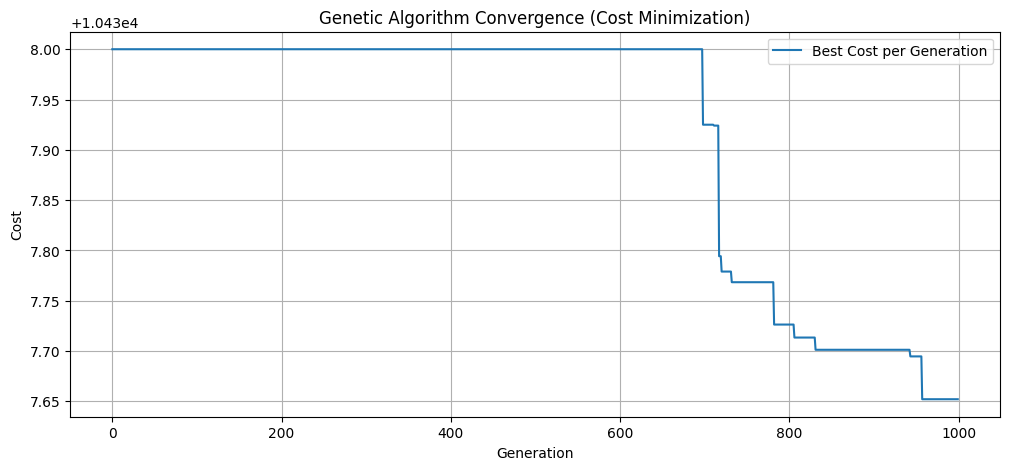

In [5]:
# 8. Main Genetic Algorithm Loop

def genetic_algorithm(pop_size, num_generations, mutation_rate, tournament_size,
                      plant_capacities_dict, city_demands_dict, transport_costs_dict, generation_costs_dict,
                      plants_list, cities_list):

    # Initialize population
    population = create_population(pop_size, plant_capacities_dict, city_demands_dict, plants_list, cities_list)

    best_individual = None
    best_fitness = -float('inf')
    best_cost = float('inf')

    history_best_fitness = []
    history_avg_fitness = []
    history_best_cost = []

    for generation in range(num_generations):
        # Evaluate fitness for each individual
        fitnesses = [fitness_function(ind, plant_capacities_dict, city_demands_dict, transport_costs_dict, generation_costs_dict, plants_list, cities_list) for ind in population]

        current_best_fitness_gen = -float('inf')
        current_best_individual_gen = None
        current_best_cost_gen = float('inf')

        for i, ind in enumerate(population):
            if fitnesses[i] > current_best_fitness_gen:
                current_best_fitness_gen = fitnesses[i]
                current_best_individual_gen = ind
                current_best_cost_gen = calculate_total_cost(ind, plant_capacities_dict, city_demands_dict, transport_costs_dict, generation_costs_dict, plants_list, cities_list)

        if current_best_fitness_gen > best_fitness:
            best_fitness = current_best_fitness_gen
            best_individual = current_best_individual_gen
            best_cost = current_best_cost_gen

        history_best_fitness.append(best_fitness)
        history_avg_fitness.append(np.mean(fitnesses))
        history_best_cost.append(best_cost)

        # Select parents for next generation
        parents = select_parents(population, fitnesses, pop_size // 2, tournament_size)

        next_population = []
        # Elitism: Keep the best individual from the current generation
        if best_individual is not None:
            next_population.append(best_individual)

        # Create offspring through crossover and mutation
        while len(next_population) < pop_size:
            parent1, parent2 = random.sample(parents, 2)
            offspring = crossover(parent1, parent2)
            offspring = mutate(offspring, mutation_rate, plant_capacities_dict, city_demands_dict, plants_list, cities_list)
            next_population.append(offspring)

        population = next_population

        if (generation + 1) % 100 == 0:
            print(f"Generation {generation + 1}/{num_generations}, Best Cost: {best_cost:.2f}, Best Fitness: {best_fitness:.6f}")

    return best_individual, best_cost, history_best_fitness, history_avg_fitness, history_best_cost

# --- GA Parameters ---
POPULATION_SIZE = 100
NUM_GENERATIONS = 1000
MUTATION_RATE = 0.1
TOURNAMENT_SIZE = 5

print("\nRunning Genetic Algorithm...")
best_solution, min_cost, hist_best_fit, hist_avg_fit, hist_best_cost = genetic_algorithm(
    POPULATION_SIZE, NUM_GENERATIONS, MUTATION_RATE, TOURNAMENT_SIZE,
    plant_capacities, city_demands, transport_costs, generation_costs_per_gw,
    plants, cities
)

print("\n--- Optimization Results ---")
print(f"Minimum Total Cost: {min_cost:.2f}")
print("Best Dispatch Plan (GW):\n", best_solution)

print("\nChecking Constraints for Best Solution:")
for i, plant_name in enumerate(plants):
    outgoing = np.sum(best_solution[i, :])
    capacity = plant_capacities[plant_name]
    print(f"  {plant_name} (Capacity: {capacity} GW): Outgoing = {outgoing:.2f} GW {'(EXCEEDS!)' if outgoing > capacity + 0.01 else '(OK)'}")

for j, city_name in enumerate(cities):
    incoming = np.sum(best_solution[:, j])
    demand = city_demands[city_name]
    print(f"  {city_name} (Demand: {demand} GW): Incoming = {incoming:.2f} GW {'(SHORT!)' if incoming < demand - 0.01 else ('(EXCEEDS!)' if incoming > demand + 0.01 else '(OK)')}")

# Optional: Plotting convergence
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(hist_best_cost, label='Best Cost per Generation')
plt.title('Genetic Algorithm Convergence (Cost Minimization)')
plt.xlabel('Generation')
plt.ylabel('Cost')
plt.legend()
plt.grid(True)
plt.show()